In [1]:
from google.colab import files
uploaded = files.upload()
for fn in uploaded.keys():
  print('User uploaded file "{name}" with length {length} bytes'.format(
      name=fn, length=len(uploaded[fn])))


Saving IMDB Dataset.csv to IMDB Dataset.csv
User uploaded file "IMDB Dataset.csv" with length 66212309 bytes


In [2]:
# STEP 1: Install required libraries
!pip install -q xgboost
import nltk
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [3]:
import pandas as pd
import re
import string
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

In [4]:
df = pd.read_csv("IMDB Dataset.csv")

In [5]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r'<.*?>', '', text)  # Remove HTML
    text = text.translate(str.maketrans('', '', string.punctuation))  # Remove punctuation
    text = re.sub(r'\d+', '', text)  # Remove numbers
    text = re.sub(r'\s+', ' ', text).strip()  # Remove extra whitespace
    return text

# Apply cleaning
df['cleaned_review'] = df['review'].apply(clean_text)

# Remove stopwords
stop_words = set(stopwords.words('english'))

def remove_stopwords(text):
    return ' '.join([word for word in text.split() if word not in stop_words])

df['cleaned_review'] = df['cleaned_review'].apply(remove_stopwords)

# Optional: Apply stemming
stemmer = PorterStemmer()

def stem_text(text):
    return ' '.join([stemmer.stem(word) for word in text.split()])

df['cleaned_review'] = df['cleaned_review'].apply(stem_text)

# Encode sentiment labels (positive -> 1, negative -> 0)
label_encoder = LabelEncoder()
df['label'] = label_encoder.fit_transform(df['sentiment'])

# Train-test split
X = df['cleaned_review']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("✅ Preprocessing complete. You're ready for TF-IDF vectorization and model training!")

✅ Preprocessing complete. You're ready for TF-IDF vectorization and model training!


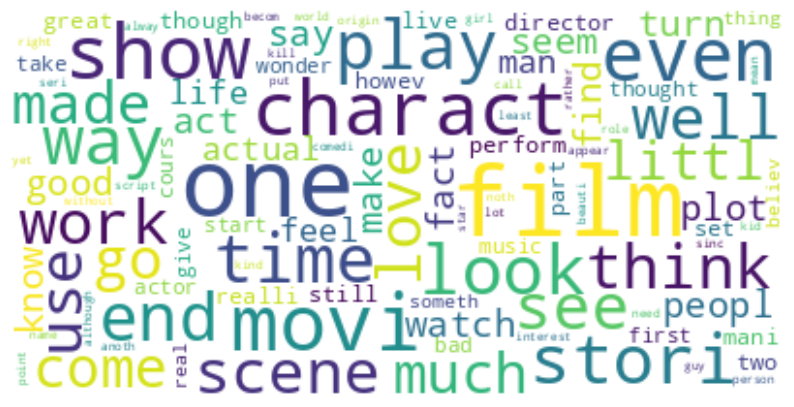

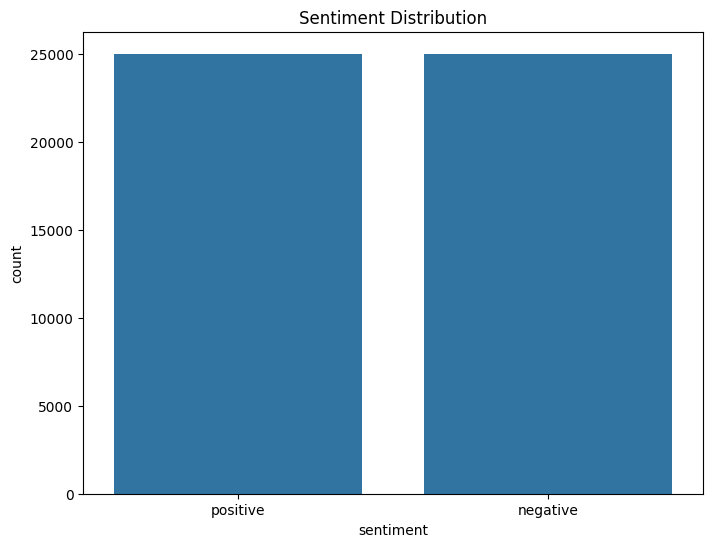

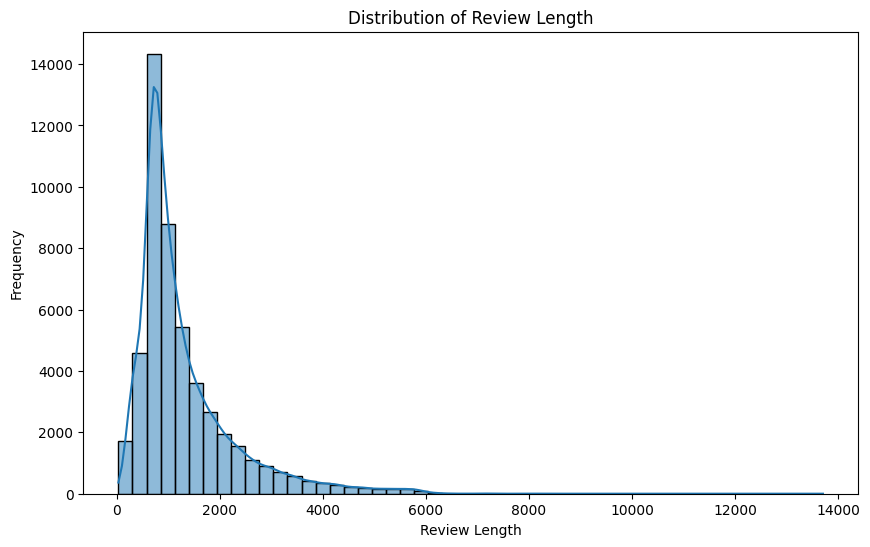

In [6]:
# prompt: give data visulization

import matplotlib.pyplot as plt
import seaborn as sns

# Word Cloud (requires wordcloud library)
!pip install wordcloud
from wordcloud import WordCloud

# Combine all reviews into a single string
text = " ".join(review for review in df.cleaned_review)

# Create and generate a word cloud image:
wordcloud = WordCloud(max_font_size=50, max_words=100, background_color="white").generate(text)

# Display the generated image:
plt.figure(figsize=(10, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.show()

# Sentiment Distribution
plt.figure(figsize=(8, 6))
sns.countplot(x='sentiment', data=df)
plt.title('Sentiment Distribution')
plt.show()

# Review Length Distribution
df['review_length'] = df['review'].apply(len)
plt.figure(figsize=(10, 6))
sns.histplot(df['review_length'], bins=50, kde=True)
plt.title('Distribution of Review Length')
plt.xlabel('Review Length')
plt.ylabel('Frequency')
plt.show()


In [7]:
# STEP 1: Vectorize text using TF-IDF
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=5000)  # You can tweak max_features if needed
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

# STEP 2: Train Logistic Regression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train_tfidf, y_train)

# STEP 3: Predict and evaluate
y_pred = lr_model.predict(X_test_tfidf)

print("🔍 Accuracy:", accuracy_score(y_test, y_pred))
print("\n📊 Classification Report:\n", classification_report(y_test, y_pred))
print("\n🧱 Confusion Matrix:\n", confusion_matrix(y_test, y_pred))


🔍 Accuracy: 0.884

📊 Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.87      0.88      4961
           1       0.87      0.90      0.89      5039

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.88     10000
weighted avg       0.88      0.88      0.88     10000


🧱 Confusion Matrix:
 [[4298  663]
 [ 497 4542]]


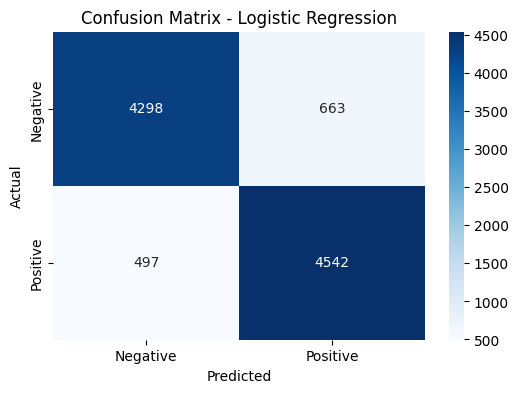

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Logistic Regression')
plt.show()


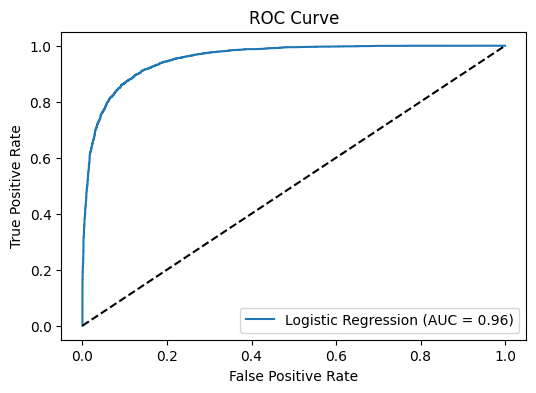

In [9]:
from sklearn.metrics import roc_curve, auc

y_probs = lr_model.predict_proba(X_test_tfidf)[:,1]  # Probability estimates for the positive class
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f'Logistic Regression (AUC = {roc_auc:.2f})')
plt.plot([0,1], [0,1], 'k--')  # Diagonal line
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()


/usr/local/lib/python3.11/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


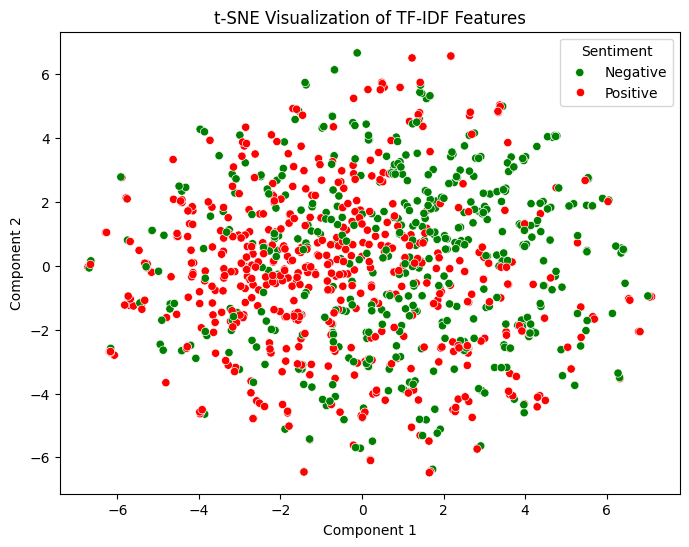

In [10]:
from sklearn.manifold import TSNE

# Reduce TF-IDF vectors to 2D for visualization
tsne = TSNE(n_components=2, random_state=42, perplexity=40, n_iter=300)
X_embedded = tsne.fit_transform(X_test_tfidf[:1000].toarray())  # Subset for performance

# Plot the 2D representation
plt.figure(figsize=(8,6))
sns.scatterplot(x=X_embedded[:,0], y=X_embedded[:,1], hue=y_test[:1000], palette=['red','green'])
plt.title("t-SNE Visualization of TF-IDF Features")
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.legend(title="Sentiment", labels=["Negative", "Positive"])
plt.show()


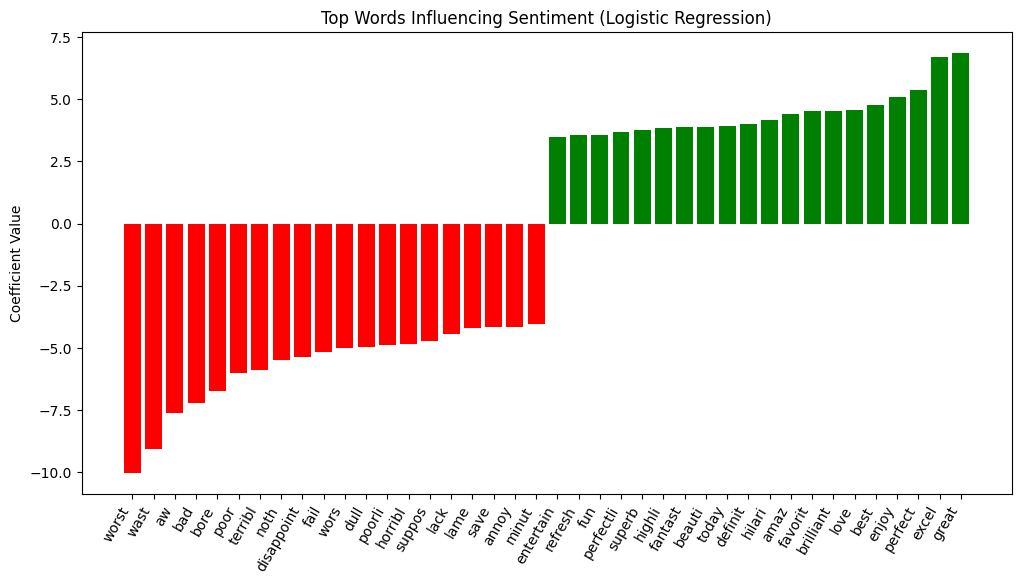

In [11]:
import numpy as np

# Get feature names and model coefficients
feature_names = tfidf.get_feature_names_out()
coefficients = lr_model.coef_[0]

# Get top 20 positive and negative coefficients
top_positive_coeffs = np.argsort(coefficients)[-20:]
top_negative_coeffs = np.argsort(coefficients)[:20]

top_words = np.hstack([top_negative_coeffs, top_positive_coeffs])
colors = ['red']*20 + ['green']*20

# Bar chart
plt.figure(figsize=(12,6))
plt.bar(np.arange(40), coefficients[top_words], color=colors)
plt.xticks(np.arange(40), feature_names[top_words], rotation=60, ha='right')
plt.title("Top Words Influencing Sentiment (Logistic Regression)")
plt.ylabel("Coefficient Value")
plt.show()
